In [10]:
import os
import cv2
import json
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm 
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True 
torch.set_float32_matmul_precision('high')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU Model: NVIDIA H200


In [2]:
# ==========================================
# Load Configuration
# ==========================================
CONFIG_PATH = "config.json"
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

PATCH_SIZE = config['train']['patch_size']
BATCH_SIZE = config['train']['batch_size'] 

SYNTHETIC_DIR = os.path.join(config['data']['output_dir'], 'synthetic_pretrain_v2')
TRAIN_IMG_DIR = os.path.join(SYNTHETIC_DIR, 'images')
TRAIN_MASK_DIR = os.path.join(SYNTHETIC_DIR, 'masks')

VAL_DIR = config['data']['labels_dir']

# ==========================================
# Data Augmentation & Preprocessing
# ==========================================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.RandomRotate90 removed to prevent dimension mismatch in non-square batches
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0, p=0.5), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(PATCH_SIZE, int(PATCH_SIZE * (7/8))), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [11]:
# 1. Training Dataset
class SanbornTrainDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = [f for f in sorted(os.listdir(image_dir)) if f.endswith(('.png', '.jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.image_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, img_name), cv2.IMREAD_GRAYSCALE)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        return image, mask.long()

# 2. Validation Dataset 
class SanbornRealValDataset(Dataset):
    def __init__(self, val_dir, transform=None):
        self.val_dir = val_dir
        self.transform = transform
        self.samples = []
        for f in sorted(os.listdir(val_dir)):
            if f.endswith('.jpg'):
                json_path = os.path.join(val_dir, f.replace('.jpg', '.json'))
                if os.path.exists(json_path):
                    self.samples.append((os.path.join(val_dir, f), json_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, json_path = self.samples[idx]
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        mask = np.zeros((h, w), dtype=np.uint8)
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        for shape in data.get('shapes', []):
            label = shape['label'] 
            points = np.array(shape['points'], dtype=np.int32)
            
            # Mapping labels to Class IDs
            class_id = 0
            if 'brick' in label or '\u7816' in label: # Matches English or Chinese 'Brick'
                class_id = 1
            elif 'wood' in label or '\u6728' in label: # Matches English or Chinese 'Wood'
                class_id = 2
                
            if class_id > 0:
                cv2.fillPoly(mask, [points], class_id)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        return image, mask.long()

# Initialize Datasets
train_dataset = SanbornTrainDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)
val_dataset = SanbornRealValDataset(VAL_DIR, transform=val_transform)

print(f"Training samples (Synthetic): {len(train_dataset)}")
print(f"Validation samples (Real): {len(val_dataset)}")

# Initialize DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

Training samples (Synthetic): 2000
Validation samples (Real): 4


In [4]:
# ==========================================
# Hybrid Loss: Addressing Class Imbalance
# ==========================================
class DiceCELoss(nn.Module):
    def __init__(self):
        super(DiceCELoss, self).__init__()
        self.dice_loss = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        # Combines Cross Entropy for pixel-wise accuracy and Dice for boundary/imbalance
        return self.ce_loss(inputs, targets) + self.dice_loss(inputs, targets)

# ==========================================
# Model Initialization (U-Net)
# ==========================================
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3 # 0: Background, 1: Brick, 2: Wood
).to(DEVICE)

criterion = DiceCELoss()
optimizer = optim.AdamW(model.parameters(), lr=config['train']['lr'], weight_decay=1e-4)

scaler = torch.amp.GradScaler('cuda')

In [12]:
EPOCHS = 10 
best_val_loss = float("inf")
save_model_path = os.path.join(config['data']['output_dir'], "unet_synth2real_best.pth")

print(f"Starting high-speed AMP training on {DEVICE}...")

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, masks in train_bar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        # Optimization: set_to_none=True is faster than zeroing gradients
        optimizer.zero_grad(set_to_none=True) 

        # Automatic Mixed Precision (AMP) Context
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, masks)

        # Scaled Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        train_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader.dataset)

    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        for images, masks in val_bar:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            
            # Inference also benefits from AMP speedup
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, masks)
                
            val_loss += loss.item() * images.size(0)
            val_bar.set_postfix(loss=loss.item())

    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1} | Synthetic Train Loss: {train_loss:.4f} | Real Val Loss: {val_loss:.4f}")

    # Save best model based on real validation performance
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_model_path)
        print(f"Improvement detected! Model saved to: {save_model_path}")

print("Training Complete!")

Starting high-speed AMP training on cuda...


Epoch 1/10 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 | Synthetic Train Loss: 0.1713 | Real Val Loss: 0.6214
Improvement detected! Model saved to: /scratch/gd2630/sanborn/output/unet_synth2real_best.pth


Epoch 2/10 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9 | Synthetic Train Loss: 0.0374 | Real Val Loss: 0.7969


Epoch 10/10 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 10 | Synthetic Train Loss: 0.0335 | Real Val Loss: 0.8128
Training Complete!


Successfully loaded best weights: /scratch/gd2630/sanborn/output/unet_synth2real_best.pth


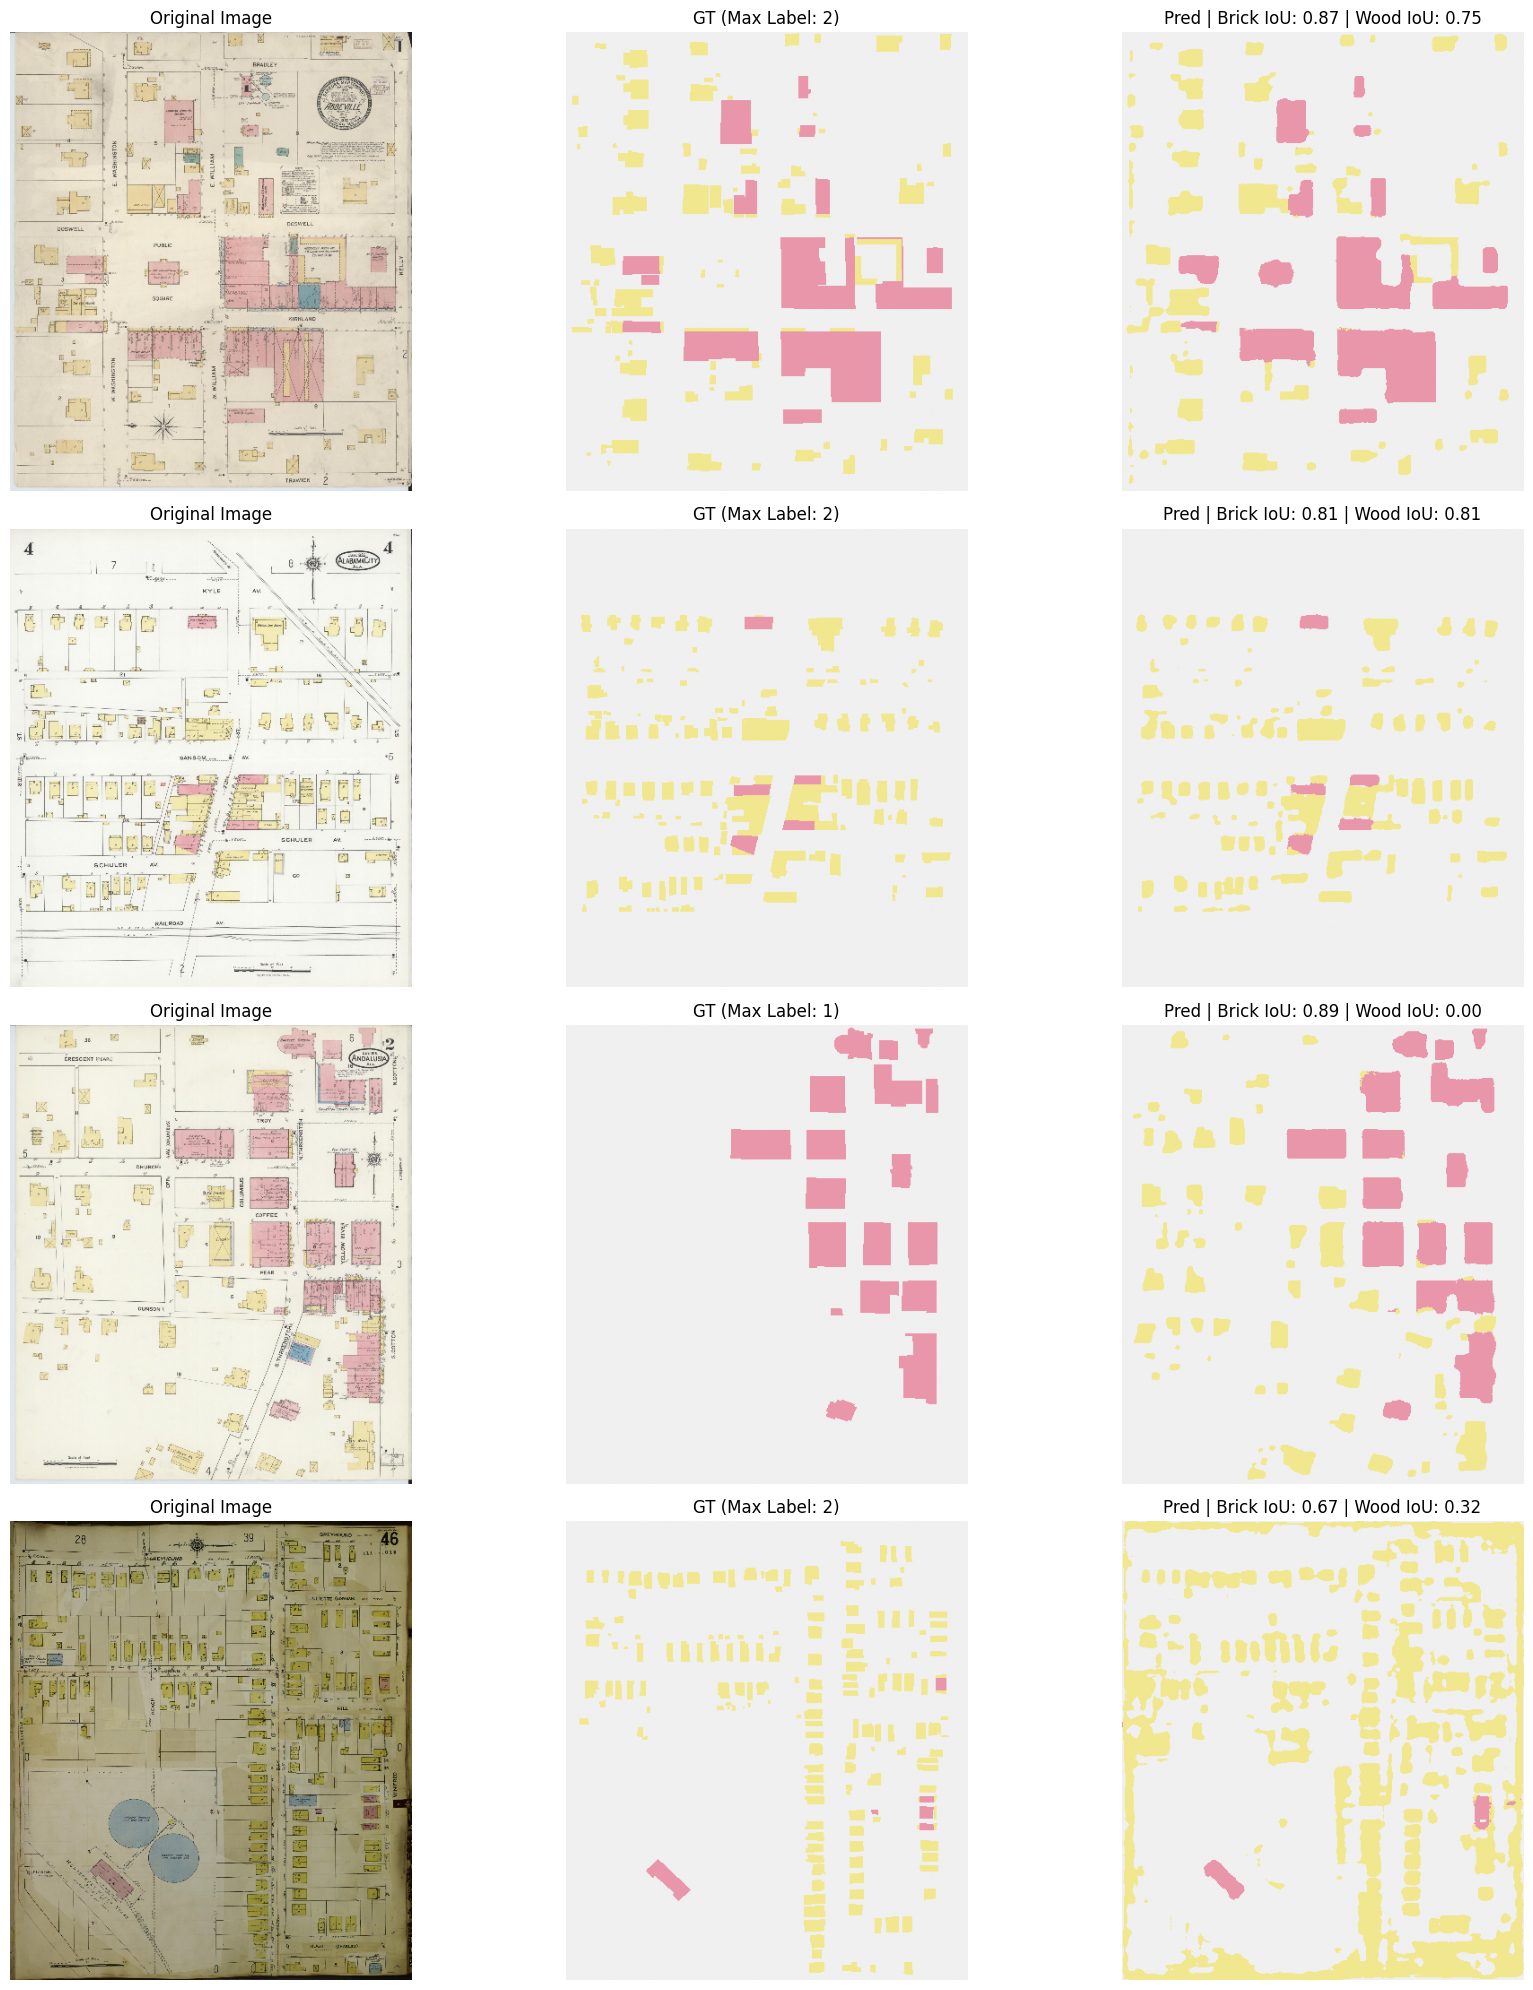

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ==========================================
# 1. Load Best Model Weights
# ==========================================
best_model_path = os.path.join(config['data']['output_dir'], "unet_synth2real_best.pth")

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"Successfully loaded best weights: {best_model_path}")
else:
    print("Warning: No saved weights found. Using current model in memory.")

model.eval()

# ==========================================
# 2. Define Color Map (Sanborn Map Aesthetics)
# ==========================================
# 0: Background (Light Grey), 1: Brick (Pink), 2: Wood (Yellow)
colors = ['#f0f0f0', '#e996aa', '#f1e78e'] 
cmap = mcolors.ListedColormap(colors)

def denormalize(img_tensor):
    """Helper to convert normalized tensor back to displayable RGB."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.transpose(1, 2, 0)
    img = (img * std) + mean
    return np.clip(img, 0, 1)

def calculate_iou(pred, target, n_classes=3):
    """Calculates Intersection over Union for each class."""
    ious = []
    for cls in range(n_classes):
        inter = ((pred == cls) & (target == cls)).sum().float().item()
        union = ((pred == cls) | (target == cls)).sum().float().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(inter / union)
    return ious

# ==========================================
# 3. Inference and Visualization
# ==========================================
images, masks = next(iter(val_loader))
images, masks = images.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# Plotting results
num_images = len(images)
fig, axes = plt.subplots(num_images, 3, figsize=(18, 5 * num_images))

for i in range(num_images):
    iou = calculate_iou(preds[i], masks[i])
    
    # Original Image (Denormalized)
    axes[i, 0].imshow(denormalize(images[i].cpu().numpy()))
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')
    
    # Ground Truth Mask
    axes[i, 1].imshow(masks[i].cpu().numpy(), cmap=cmap, vmin=0, vmax=2)
    axes[i, 1].set_title(f"GT (Max Label: {masks[i].max()})")
    axes[i, 1].axis('off')
    
    # Model Prediction + IoU Metrics
    axes[i, 2].imshow(preds[i].cpu().numpy(), cmap=cmap, vmin=0, vmax=2)
    axes[i, 2].set_title(f"Pred | Brick IoU: {iou[1]:.2f} | Wood IoU: {iou[2]:.2f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()